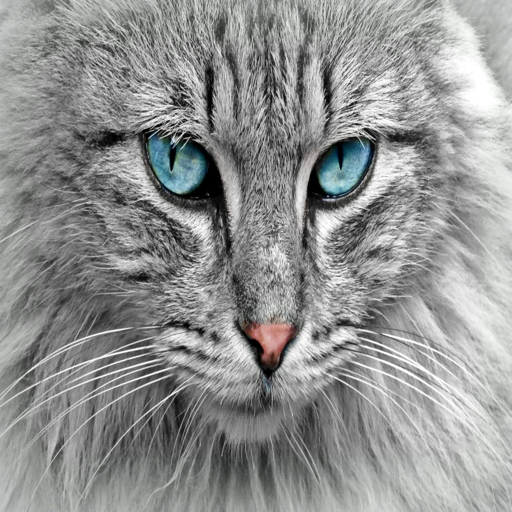

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

image_colored = Image.open(r"D:\Herald_College\6th Semester\6CS012_Mandeep_Panta_2408124\cat.png")
image_colored = image_colored.resize(( 512 , 512 ))

display(image_colored)

In [ ]:

# Load image and convert to grayscale
image = Image.open(r"D:\Herald_College\6th Semester\6CS012_Mandeep_Panta_2408124\cat.png").convert ("L")
# Convert to NumPy array
image_array = np.array(image)
# Get image dimensions
height , width = image_array.shape
# Reshape the image into a 2D array where each row represents a row of pixels
# This allows PCA to process each row as an observation and find patterns across pixel intensities
data = image_array.reshape(height , width)

In [ ]:
# Compute the mean of each column ( feature )
mean = np.mean(data , axis = 0)
# Subtract mean to center the data
centered_data = data - mean# Compute the mean of each column ( feature )
mean = np.mean(data , axis = 0)
# Subtract mean to center the data
centered_data = data - mean

In [ ]:
# Compute covariance matrix
cov_matrix = np.cov(centered_data , rowvar = False)

In [ ]:
# Compute eigenvalues and eigenvectors
eigenvalues , eigenvectors = np.linalg.eigh(cov_matrix)
# Sort eigenvalues and corresponding eigenvectors indescending order
sorted_indices = np.argsort(eigenvalues)[:: -1]
eigenvalues = eigenvalues [sorted_indices]
eigenvectors = eigenvectors [: , sorted_indices]

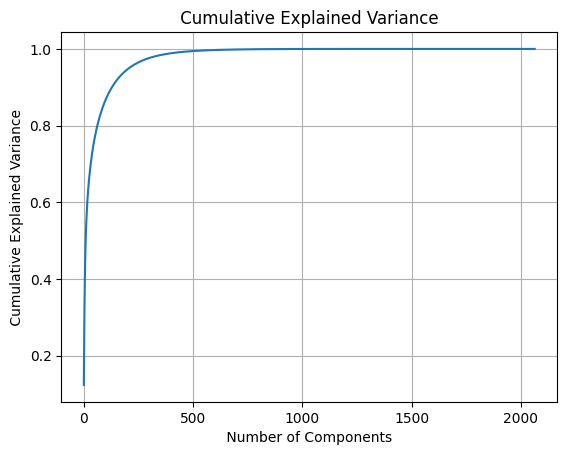

In [ ]:
# Plot the explained variance ratio
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
plt.plot(np.cumsum(explained_variance_ratio))
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

In [12]:
k = 50 # Choose k principal components
components = eigenvectors [: , : k ]

In [ ]:
# Project the data onto the principal components
compressed_data = np.dot(centered_data , components)

In [ ]:
# Reconstruct the image from compressed data
decompressed_data = np.dot(compressed_data , components . T ) + mean

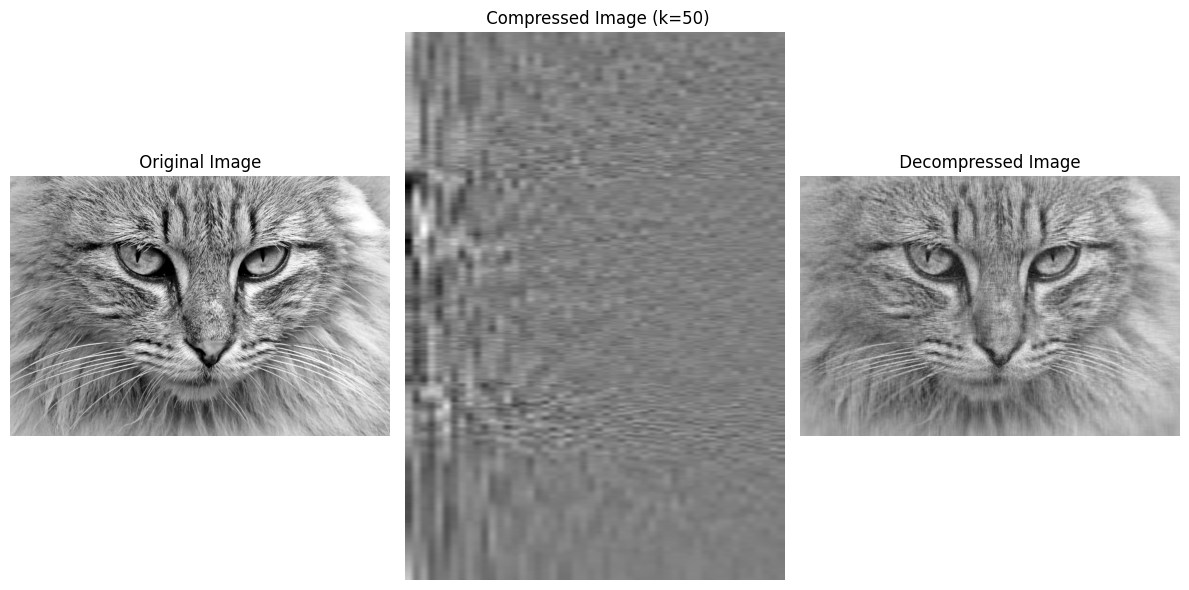

In [ ]:
plt.figure ( figsize =(12 , 6) )
# Original Image
plt.subplot(1 , 3 , 1)
plt.imshow(image_array , cmap ="gray")
plt.title("Original Image")
plt.axis("off")
# Compressed Representation
plt.subplot(1 , 3 , 2)
plt.imshow(compressed_data , cmap ="gray", aspect ="auto")
plt.title(f"Compressed Image (k={k})")
plt.axis("off")
# Decompressed Image
plt.subplot(1 , 3 , 3)
plt.imshow(decompressed_data , cmap ="gray")
plt.title("Decompressed Image")
plt.axis("off")
plt.tight_layout()
plt.show()

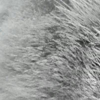

In [16]:
# Define the cropping box (left, upper, right, lower)
left = 0
upper = 0
right = 100
lower = 100

# Crop the image (assign the result!)
cropped_image = image_colored.crop((left, upper, right, lower))

# Display the cropped image
display(cropped_image)

In [ ]:
# Convert the Pillow image to a NumPy array
image_array_colored = np.array( image_colored )
# Display the shape of the NumPy array (height , width , channels)
print (" Shape of the image array :", image_array_colored .shape)

 Shape of the image array : (512, 512, 4)


In [ ]:
# Convert the Pillow image to a NumPy array
image_array_colored = np.array(image_colored)
# Display the shape of the NumPy array (height , width ,channels)
print (" Shape of the image array :", image_array_colored . shape)
#For Red Channels
red_channel = image_array_colored.copy() # Red channel
red_channel [: , : , 1] = 0 # Green channel
red_channel [: , : , 2] = 0
display (red_channel)


 Shape of the image array : (512, 512, 4)


array([[[184,   0,   0, 255],
        [186,   0,   0, 255],
        [183,   0,   0, 255],
        ...,
        [194,   0,   0, 255],
        [192,   0,   0, 255],
        [191,   0,   0, 255]],

       [[190,   0,   0, 255],
        [187,   0,   0, 255],
        [181,   0,   0, 255],
        ...,
        [192,   0,   0, 255],
        [193,   0,   0, 255],
        [192,   0,   0, 255]],

       [[191,   0,   0, 255],
        [183,   0,   0, 255],
        [185,   0,   0, 255],
        ...,
        [193,   0,   0, 255],
        [194,   0,   0, 255],
        [193,   0,   0, 255]],

       ...,

       [[189,   0,   0, 255],
        [192,   0,   0, 255],
        [190,   0,   0, 255],
        ...,
        [172,   0,   0, 255],
        [179,   0,   0, 255],
        [199,   0,   0, 255]],

       [[189,   0,   0, 255],
        [190,   0,   0, 255],
        [184,   0,   0, 255],
        ...,
        [171,   0,   0, 255],
        [171,   0,   0, 255],
        [192,   0,   0, 255]],

       [[191

In [ ]:
# For Blue Channel :
blue_channel = image_array_colored.copy() # Blue channel
blue_channel [: , : , 0] = 0 # red channel
blue_channel [: , : , 1] = 0 # green channel


display ( blue_channel )

array([[[  0,   0, 187, 255],
        [  0,   0, 189, 255],
        [  0,   0, 186, 255],
        ...,
        [  0,   0, 197, 255],
        [  0,   0, 195, 255],
        [  0,   0, 194, 255]],

       [[  0,   0, 193, 255],
        [  0,   0, 190, 255],
        [  0,   0, 184, 255],
        ...,
        [  0,   0, 195, 255],
        [  0,   0, 196, 255],
        [  0,   0, 195, 255]],

       [[  0,   0, 194, 255],
        [  0,   0, 186, 255],
        [  0,   0, 188, 255],
        ...,
        [  0,   0, 196, 255],
        [  0,   0, 197, 255],
        [  0,   0, 196, 255]],

       ...,

       [[  0,   0, 192, 255],
        [  0,   0, 195, 255],
        [  0,   0, 193, 255],
        ...,
        [  0,   0, 175, 255],
        [  0,   0, 182, 255],
        [  0,   0, 202, 255]],

       [[  0,   0, 192, 255],
        [  0,   0, 193, 255],
        [  0,   0, 187, 255],
        ...,
        [  0,   0, 174, 255],
        [  0,   0, 174, 255],
        [  0,   0, 195, 255]],

       [[  0

In [ ]:
# For Blue Channel :
green_channel = image_array_colored.copy() # Blue channel
green_channel [: , : , 0] = 0 # red channel
green_channel [: , : , 2] = 0 # blue channel


display ( green_channel )

array([[[  0, 188,   0, 255],
        [  0, 190,   0, 255],
        [  0, 187,   0, 255],
        ...,
        [  0, 198,   0, 255],
        [  0, 196,   0, 255],
        [  0, 195,   0, 255]],

       [[  0, 194,   0, 255],
        [  0, 191,   0, 255],
        [  0, 185,   0, 255],
        ...,
        [  0, 196,   0, 255],
        [  0, 197,   0, 255],
        [  0, 196,   0, 255]],

       [[  0, 195,   0, 255],
        [  0, 187,   0, 255],
        [  0, 189,   0, 255],
        ...,
        [  0, 197,   0, 255],
        [  0, 198,   0, 255],
        [  0, 197,   0, 255]],

       ...,

       [[  0, 193,   0, 255],
        [  0, 196,   0, 255],
        [  0, 194,   0, 255],
        ...,
        [  0, 176,   0, 255],
        [  0, 183,   0, 255],
        [  0, 203,   0, 255]],

       [[  0, 193,   0, 255],
        [  0, 194,   0, 255],
        [  0, 188,   0, 255],
        ...,
        [  0, 175,   0, 255],
        [  0, 175,   0, 255],
        [  0, 196,   0, 255]],

       [[  0

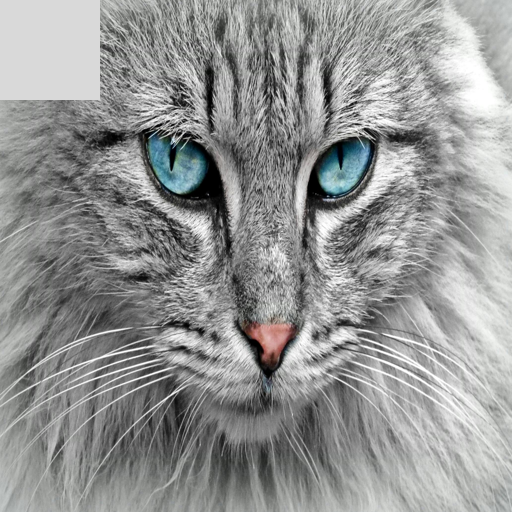

In [21]:
import numpy as np
from PIL import Image

# Convert the colored image to a NumPy array
modified_image_array = np.array(image_colored)

# Modify the top-left 100x100 pixels to a value of 210
# For an RGB image, we need to set all three channels (R, G, B) to 210
modified_image_array[0:100, 0:100, :] = 210

# Convert the NumPy array back to a PIL Image
modified_image = Image.fromarray(modified_image_array)

# Display the modified image
display(modified_image)